# 02 — Rule-Based Scoring Model & Backtesting Engine

Part 2 of the hippique-prediction pipeline. Backtests five scoring models on 61 days of historical trot data stored in DuckDB.

**Models:**
- M0 Baseline: 1 / morning_odds (market-implied)
- M1 Form: form_score only
- M2 Market: morning_implied_prob_norm × (1 - drift × 0.5)
- M4 Combined: weighted rank-normalised sum of all features
- M4-opt: grid-search optimised weights

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from config.settings import DB_PATH
from src.features.pipeline import compute_features
from src.model.scorer import score_baseline, score_form, score_market, score_combined, optimize_weights
from src.model.backtest import backtest

conn = duckdb.connect(str(DB_PATH), read_only=True)
features = compute_features(conn)

print(f'Races:   {features.race_id.nunique():,}')
print(f'Runners: {len(features):,}')
print(f'Date range: {features.date.min()} → {features.date.max()}')
print()

pct = lambda col: f'{features[col].notna().mean():.1%}'
print(f'Coverage — form_score: {pct("form_score")}  |  morning_odds: {pct("morning_odds")}  |  jockey_win_rate: {pct("jockey_win_rate")}')

Races:   1,422
Runners: 12,685
Date range: 20251228 → 20260225

Coverage — form_score: 93.3%  |  morning_odds: 83.2%  |  jockey_win_rate: 100.0%


## 2. Model Comparison — Win Bets

In [2]:
models = [
    ('M0-baseline', score_baseline),
    ('M1-form',     score_form),
    ('M2-market',   score_market),
    ('M4-combined', score_combined),
]

reports = {}
rows = []
for name, fn in models:
    r = backtest(features, fn, name, bet_type='win')
    reports[name] = r
    rows.append({
        'Model':    name,
        'Bets':     len(r.bets),
        'Hit Rate': f'{r.hit_rate:.1%}',
        'Total P&L': f'{sum(b.pnl for b in r.bets):.1f}u',
        'ROI':      f'{r.roi:.1%}',
    })

pd.DataFrame(rows).set_index('Model')

,Bets,Hit Rate,Total P&L,ROI
Model,,,,
M0-baseline,1409,39.2%,324.1u,23.0%
M1-form,1409,24.1%,637.8u,45.3%
M2-market,1409,40.7%,560.3u,39.8%
M4-combined,1409,42.3%,1741.4u,123.6%


## 3. Cumulative P&L Curve

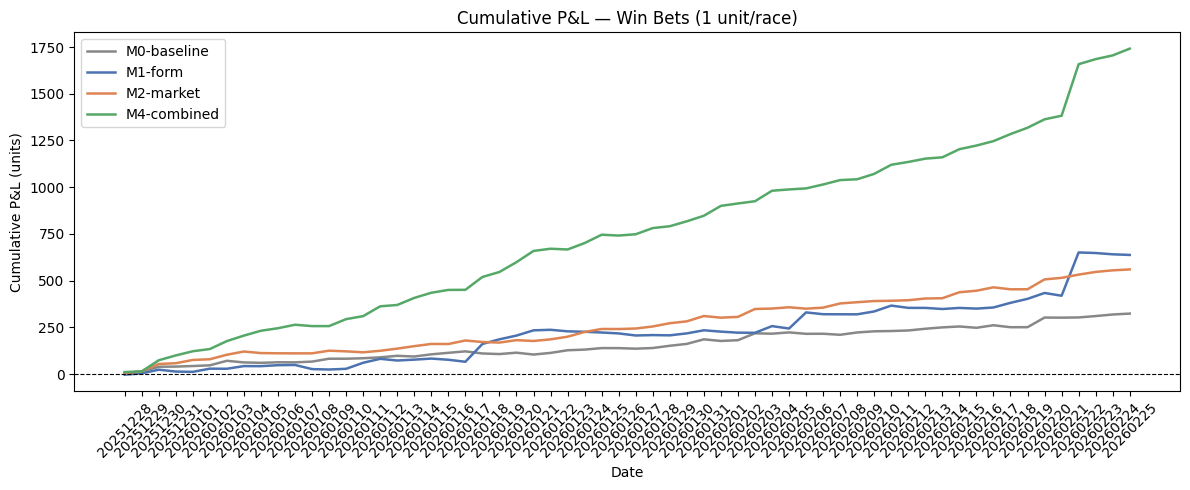

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

colours = ['#888888', '#4C72B0', '#DD8452', '#55A868']
for (name, _), colour in zip(models, colours):
    series = reports[name].pnl_series()
    ax.plot(series.index, series.values, label=name, color=colour, linewidth=1.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative P&L — Win Bets (1 unit/race)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative P&L (units)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Feature Correlations with Win

                          Spearman rho    p-value
Feature                                          
morning_odds_rank               -0.344  7.42e-292
odds_drift_pct                  -0.184   7.93e-81
morning_implied_prob_norm        0.352  1.86e-306
form_score                       0.175   1.39e-81
jockey_win_rate                  0.349   0.00e+00


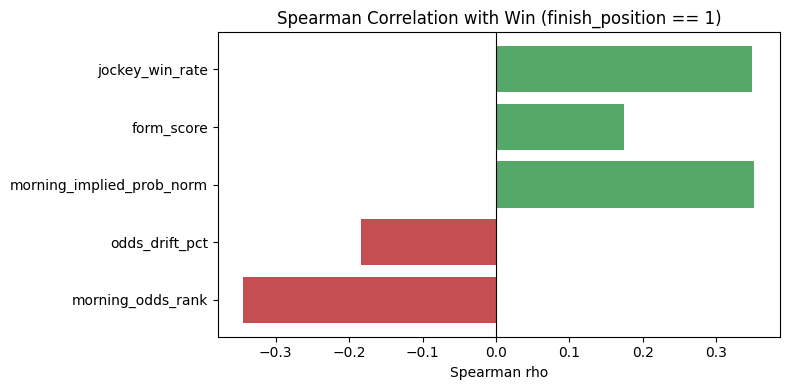

In [4]:
from scipy.stats import spearmanr

features['is_winner'] = (features['finish_position'] == 1).astype(int)

feature_cols = ['morning_odds_rank', 'odds_drift_pct', 'morning_implied_prob_norm',
                'form_score', 'jockey_win_rate']

corr_rows = []
for col in feature_cols:
    valid = features[['is_winner', col]].dropna()
    rho, pval = spearmanr(valid[col], valid['is_winner'])
    corr_rows.append({'Feature': col, 'Spearman rho': f'{rho:.3f}', 'p-value': f'{pval:.2e}'})

corr_df = pd.DataFrame(corr_rows).set_index('Feature')
print(corr_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
rhos = [float(r['Spearman rho']) for r in corr_rows]
colours_bar = ['#55A868' if r > 0 else '#C44E52' for r in rhos]
ax.barh([r['Feature'] for r in corr_rows], rhos, color=colours_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman Correlation with Win (finish_position == 1)')
ax.set_xlabel('Spearman rho')
plt.tight_layout()
plt.show()

## 5. EV+ Filter Impact

In [5]:
thresholds = [0.8, 1.0, 1.2]
ev_rows = []

for threshold in thresholds:
    r = backtest(features, score_combined, f'M4-ev{threshold}',
                 bet_type='win', ev_filter=True, ev_threshold=threshold)
    ev_rows.append({
        'EV threshold': threshold,
        'Bets': len(r.bets),
        'Hit Rate': f'{r.hit_rate:.1%}',
        'ROI': f'{r.roi:.1%}',
        'Total P&L': f'{sum(b.pnl for b in r.bets):.1f}u',
    })

# Add no-filter baseline
r_no_ev = reports['M4-combined']
ev_rows.insert(0, {
    'EV threshold': 'none',
    'Bets': len(r_no_ev.bets),
    'Hit Rate': f'{r_no_ev.hit_rate:.1%}',
    'ROI': f'{r_no_ev.roi:.1%}',
    'Total P&L': f'{sum(b.pnl for b in r_no_ev.bets):.1f}u',
})

pd.DataFrame(ev_rows).set_index('EV threshold')

,Bets,Hit Rate,ROI,Total P&L
EV threshold,,,,
none,1409,42.3%,123.6%,1741.4u
0.8,661,35.4%,206.6%,1365.4u
1.0,472,32.2%,238.6%,1126.0u
1.2,354,31.6%,271.1%,959.8u


## 6. Bet Type Comparison

In [6]:
bet_rows = []
for bt in ['win', 'place', 'duo']:
    r = backtest(features, score_combined, f'M4-{bt}', bet_type=bt)
    bet_rows.append({
        'Bet Type': bt,
        'Bets': len(r.bets),
        'Hit Rate': f'{r.hit_rate:.1%}',
        'ROI': f'{r.roi:.1%}',
        'Total P&L': f'{sum(b.pnl for b in r.bets):.1f}u',
    })

pd.DataFrame(bet_rows).set_index('Bet Type')

,Bets,Hit Rate,ROI,Total P&L
Bet Type,,,,
win,1409,42.3%,123.6%,1741.4u
place,1409,72.2%,7.4%,104.7u
duo,1409,21.3%,100.9%,2843.8u


## 7. Weight Optimisation

In [7]:
print('Running grid search (~500 combinations)...')
best_weights, opt_df = optimize_weights(features, bet_type='win')

print(f'Best weights: {best_weights}')
print(f'Best ROI:     {opt_df.iloc[0]["roi"]:.1%}')
print()
print('Top 10 combinations:')
opt_df.head(10)[['w_form','w_odds','w_drift','w_jockey','roi','hit_rate','n_bets','total_pnl']].to_string(index=False)

Running grid search (~500 combinations)...


Best weights: {'w_form': np.float64(0.5), 'w_odds': np.float64(0.0), 'w_drift': np.float64(0.5), 'w_jockey': np.float64(0.75)}
Best ROI:     250.5%

Top 10 combinations:


' w_form  w_odds  w_drift  w_jockey      roi  hit_rate  n_bets  total_pnl\n   0.50    0.00     0.50      0.75 2.504684  0.427253    1409     3529.1\n   0.50    0.00     0.50      1.00 2.466785  0.433641    1409     3475.7\n   0.25    0.00     0.25      0.50 2.466785  0.433641    1409     3475.7\n   0.25    0.00     0.75      1.00 2.459049  0.418027    1409     3464.8\n   0.00    0.25     0.50      1.00 2.458907  0.452094    1409     3464.6\n   0.25    0.25     0.50      1.00 2.458765  0.459191    1409     3464.4\n   0.00    0.00     0.50      0.75 2.457488  0.413059    1409     3462.6\n   0.50    0.00     0.75      1.00 2.457062  0.419446    1409     3462.0\n   0.25    0.00     0.25      0.75 2.454933  0.438609    1409     3459.0\n   0.25    0.00     0.50      0.75 2.446984  0.430092    1409     3447.8'

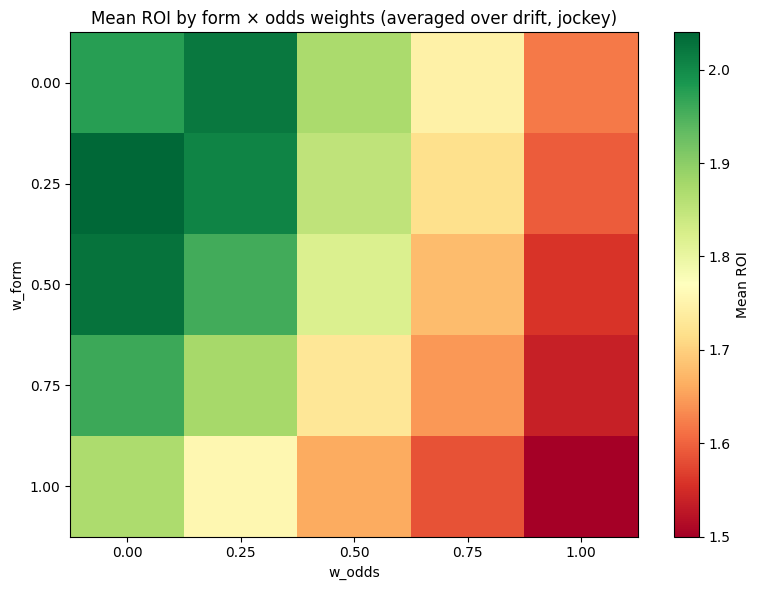

In [8]:
# Heatmap: form weight vs odds weight, averaged over drift/jockey
form_vals = sorted(opt_df['w_form'].unique())
odds_vals = sorted(opt_df['w_odds'].unique())

pivot = opt_df.groupby(['w_form', 'w_odds'])['roi'].mean().unstack('w_odds')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.2f}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{v:.2f}' for v in pivot.index])
ax.set_xlabel('w_odds')
ax.set_ylabel('w_form')
ax.set_title('Mean ROI by form × odds weights (averaged over drift, jockey)')
plt.colorbar(im, ax=ax, label='Mean ROI')
plt.tight_layout()
plt.show()